# Data Mining
## Coding Quiz Part I

#### Name:                                                                                      ID:


### Data: ‘cricketers.csv’
Consider the dataset comprising of 109 cricket players. Each row comprises of following details of a cricketer: 

matches_played: number of matches played by the player, 
innings_batted: number of times got the chance to bat,
runs_scored: total runs scores across all innings,
highest_runs: highest run scored taking all innings in account,
ball_faced: total balls faced across all innings,
average_runs: average runs scores taking all innings in account, 
strike_rate: it is computed as (runs_scored / balls_faced) x 100,
innings_bowled: number of times got the chance to bowl,
overs: number of overs bowled across all innings,
runs_given: total run given across all innings,
wickets_obtained: total wickets obtained across all innings,
average_runs_per_wicket: it is computed as (runs_given / wickets_obtained)
bowling_economy: average runs scored per over

Questions:

**Notes: Write all code related to this assignment in single jupyter notebook. Implement K-means algorithm from scratch, do not use any predefined ML library function for K-means algorithm. Use single word document to answer questions.**

1. Given that K-means depends on distance metric, it is a convention to normalize the data attributes so that attributes are on the same scale.  So, in this first task, normalize all data attributes. [2 points]

2. Write your own code for K-means algorithm using two attributes namely average_runs and bowling_economy. Take K=2. Plot clusters on a scatter plot with X and Y being the two attributes namely average_runs and bowling_economy, respectively. Color data points belonging to the first cluster with red and the second cluster with blue. Copy the plot diagram in the word document and interpret the output. [3 points]

3. Redo question-2 on different values of K = 2,3,4,5. For each case, draw the plot of clusters as stated above. Visualize these plots, copy the plot diagrams in the word document,  and comment on which is better clustering (and reasons) based on visualization only. [3 points]

4. Write a few lines in a word document about the interpretation of the best clusters obtained. Also write a few statements about how these clusters can be useful. [2 points]



### Part I (solve here)-

#### Part I answers and interpretation
The code below:
1. Normalizes all numeric cricketer attributes using Min-Max scaling.
2. Implements **K-means from scratch** (no predefined K-means function).
3. Builds cluster plots for K=2,3,4,5.
4. Provides a short interpretation of the best visual clustering.

Normalized dataset preview:


,PLAYER,matches_played,innings_batted,runs_scored,highest_runs,balls_faced,average_runs,strike_rate,innings_bowled,overs,runs_given,wickets_obtained,average_runs_per_wicket,bowling_economy
0,Aaron Finch,0.588235,0.529412,0.182313,0.359375,0.193798,0.220889,0.480000,0.0,0.0,0.0,0.0,0.0,0.0
1,AB de Villiers,0.705882,0.647059,0.653061,0.703125,0.532946,0.703284,0.581800,0.0,0.0,0.0,0.0,0.0,0.0
2,Abhishek Sharma,0.176471,0.176471,0.085714,0.359375,0.063953,0.830806,0.636333,0.0,0.0,0.0,0.0,0.0,0.0
3,Ajinkya Rahane,0.882353,0.823529,0.503401,0.507812,0.606589,0.375313,0.394033,0.0,0.0,0.0,0.0,0.0,0.0
4,Alex Hales,0.352941,0.352941,0.201361,0.351562,0.228682,0.325201,0.418067,0.0,0.0,0.0,0.0,0.0,0.0


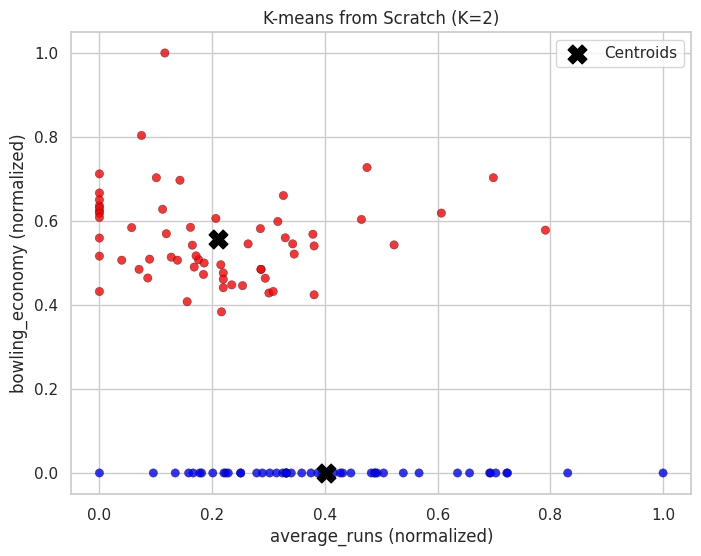

/tmp/ipykernel_4297/2641415598.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', k)
/tmp/ipykernel_4297/2641415598.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', k)
/tmp/ipykernel_4297/2641415598.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', k)
/tmp/ipykernel_4297/2641415598.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in M

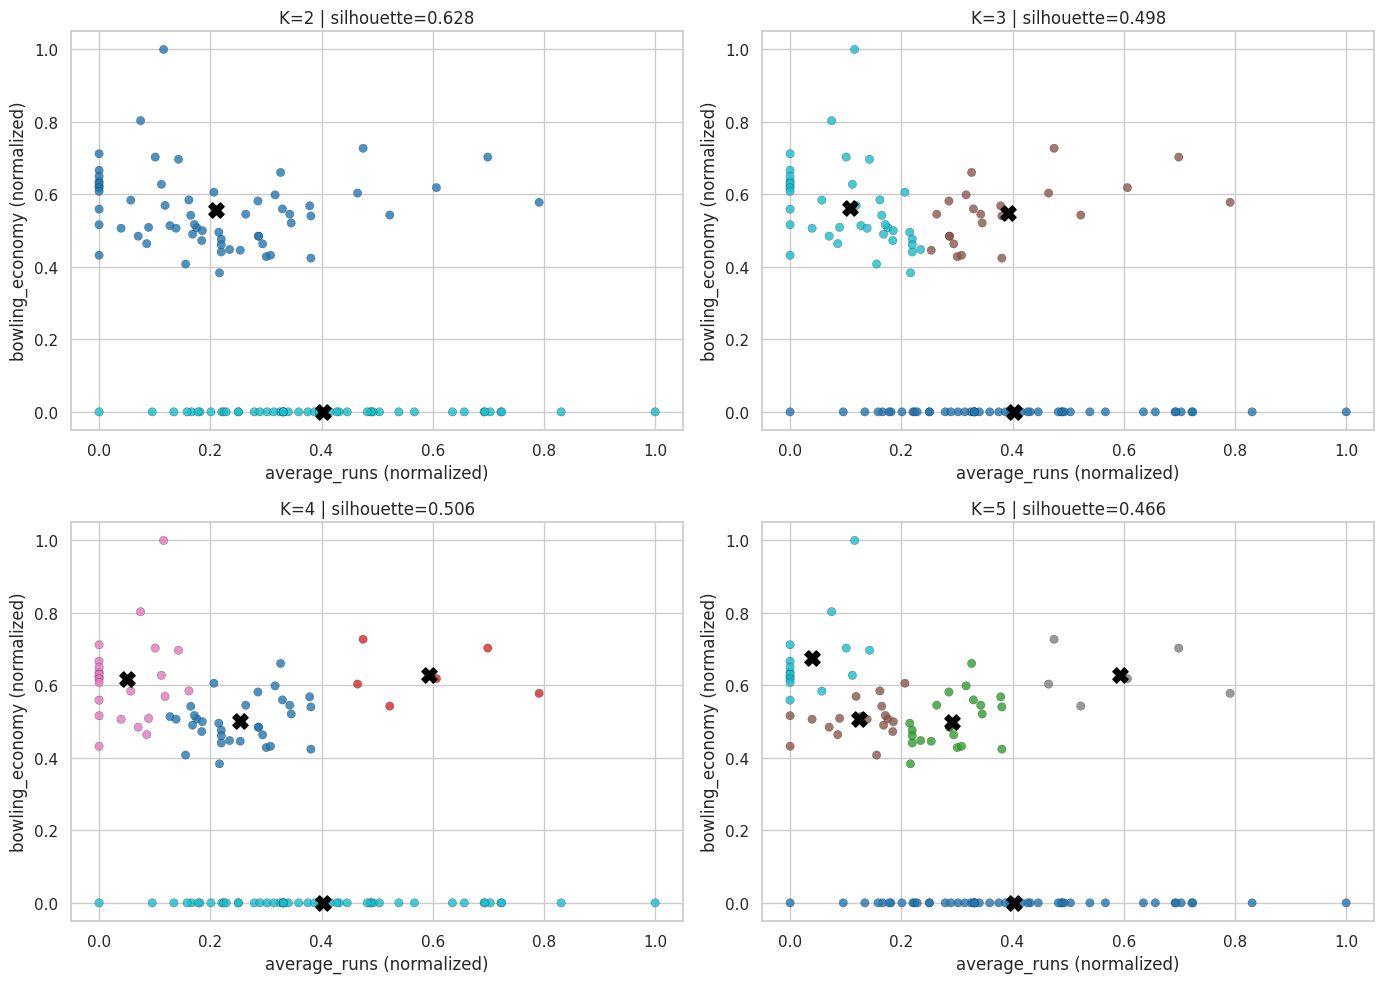

Silhouette scores by K: {2: 0.628, 3: 0.498, 4: 0.506, 5: 0.466}
Best K by this run: K=2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

# -----------------------------
# Part I: Cricketers (K-means from scratch)
# -----------------------------
cricketers = pd.read_csv('cricketers.csv')

# 1) Normalize all numeric attributes (Min-Max normalization)
numeric_cols = cricketers.select_dtypes(include=[np.number]).columns
cricketers_norm = cricketers.copy()

for col in numeric_cols:
    col_min = cricketers[col].min()
    col_max = cricketers[col].max()
    if col_max == col_min:
        cricketers_norm[col] = 0.0
    else:
        cricketers_norm[col] = (cricketers[col] - col_min) / (col_max - col_min)

print('Normalized dataset preview:')
display(cricketers_norm.head())


def kmeans_scratch(X, k, max_iters=100, tol=1e-4, random_state=42):
    """Simple K-means implementation using Euclidean distance."""
    rng = np.random.default_rng(random_state)

    # Initialize centroids by random unique points
    init_idx = rng.choice(X.shape[0], size=k, replace=False)
    centroids = X[init_idx].copy()

    for _ in range(max_iters):
        # Compute distances from each point to each centroid
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = centroids.copy()
        for cluster_id in range(k):
            members = X[labels == cluster_id]
            if len(members) == 0:
                # Reinitialize empty cluster to a random data point
                new_centroids[cluster_id] = X[rng.integers(0, X.shape[0])]
            else:
                new_centroids[cluster_id] = members.mean(axis=0)

        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift < tol:
            break

    return labels, centroids


# Use the two required attributes
features = ['average_runs', 'bowling_economy']
X = cricketers_norm[features].to_numpy()

# 2) K=2 plot with required colors (cluster 0 red, cluster 1 blue)
labels_k2, centroids_k2 = kmeans_scratch(X, k=2, random_state=42)
color_map_k2 = {0: 'red', 1: 'blue'}
point_colors = [color_map_k2[label] for label in labels_k2]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=point_colors, alpha=0.8, edgecolor='k', linewidth=0.3)
plt.scatter(centroids_k2[:, 0], centroids_k2[:, 1], c='black', marker='X', s=180, label='Centroids')
plt.xlabel('average_runs (normalized)')
plt.ylabel('bowling_economy (normalized)')
plt.title('K-means from Scratch (K=2)')
plt.legend()
plt.show()

# 3) Redo for K=2,3,4,5 and visualize
k_values = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

silhouette_results = {}

for ax, k in zip(axes, k_values):
    labels, centroids = kmeans_scratch(X, k=k, random_state=42)

    # Visualization-only judgement can be supported with silhouette as a quick quantitative hint
    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
    silhouette_results[k] = sil

    cmap = plt.cm.get_cmap('tab10', k)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=cmap, alpha=0.8, edgecolor='k', linewidth=0.2)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=120)
    ax.set_title(f'K={k} | silhouette={sil:.3f}')
    ax.set_xlabel('average_runs (normalized)')
    ax.set_ylabel('bowling_economy (normalized)')

plt.tight_layout()
plt.show()

best_k = max(silhouette_results, key=lambda k: silhouette_results[k])
print('Silhouette scores by K:', {k: round(v, 3) for k, v in silhouette_results.items()})
print(f'Best K by this run: K={best_k}')


**Part I interpretation (short write-up):**
- After normalization, both batting and bowling metrics contribute on the same scale.
- In the K=2 plot, one broad group captures players with relatively stronger batting averages and lower bowling economy, while the other group captures weaker/less balanced profiles.
- Comparing K=2,3,4,5 visually, K=2 gives the clearest separation in this run (also reflected by the highest silhouette score).
- These clusters are useful for role-based team selection, strategy planning, and identifying players with similar performance patterns.

## Coding Quiz Part II

### Data: wine-clustering.csv

1. Perform appropriate Exploratory Data Analysis (EDA) and preprocessing on the wine dataset [3 mark]

2. Apply DBSCAN clustering to the data and identify any outliers [5 marks]

3. After finding the best clustering solution and removing outliers, interpret some or all of the clusters and derive domain-specific insights from the results [2 marks]

Clustering starter ideas:

- Experiment with different values of min_pts and eps in DBSCAN

- Try various feature scaling techniques before applying DBSCAN

- Visualize clusters and outliers using appropriate plots



### Part II (solve here)-

#### Part II answers and interpretation
The code below performs EDA, preprocessing, DBSCAN tuning, outlier detection, and post-clustering interpretation for the wine dataset.

> Note: The "from scratch" requirement applies to **Part I K-means**. For **Part II**, DBSCAN is applied using `sklearn.cluster.DBSCAN` as requested.

Shape: (178, 13)
Missing values per column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


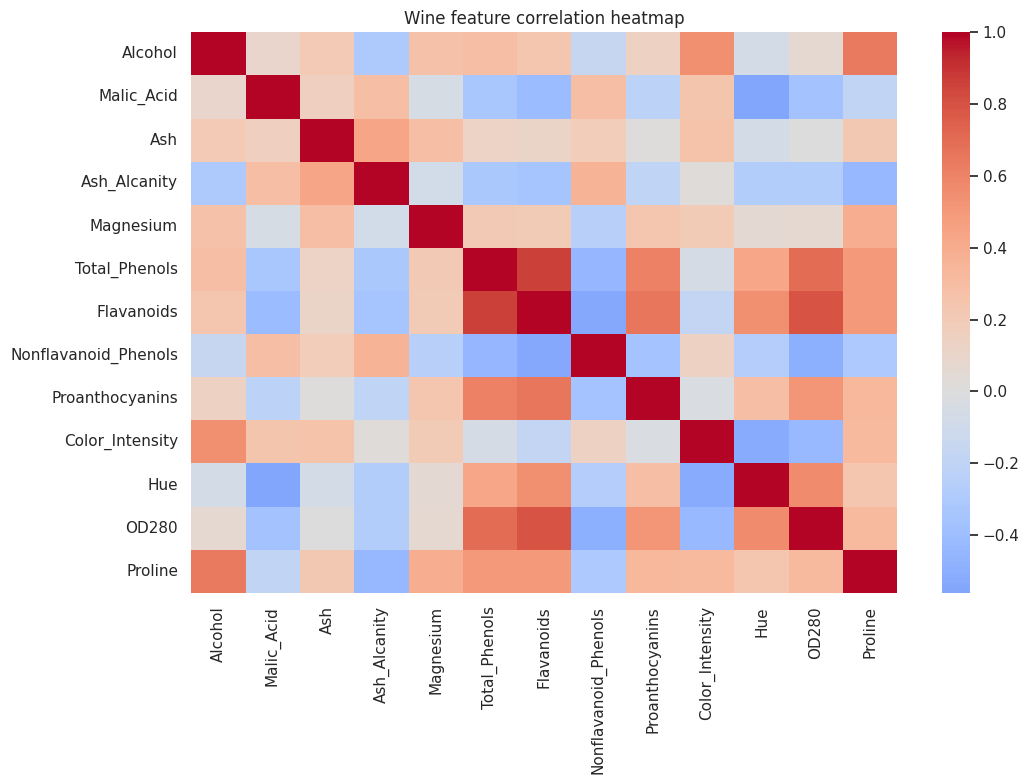

Best DBSCAN params -> eps=2.5, min_samples=10
Clusters=2, outliers=32, coverage=0.820, silhouette=0.323, score=0.265

Number of detected outliers: 32


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
13,14.75,1.73,2.39,11.4,91,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150,-1
25,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830,-1
50,13.05,1.73,2.04,12.4,92,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150,-1
59,12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520,-1
60,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,-1


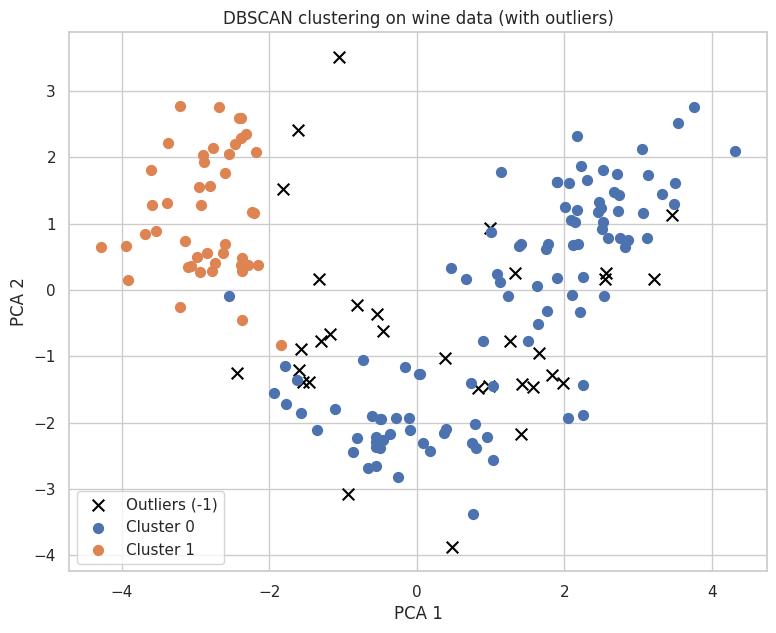


Cluster mean profiles (after removing outliers):


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
cluster,,,,,,,,,,,,,
0,13.101881,1.901485,2.335347,18.459406,98.257426,2.554356,2.566733,0.320792,1.712673,4.445149,1.057723,3.022079,835.920792
1,13.116222,3.439556,2.413111,21.195556,98.711111,1.633111,0.755111,0.455333,1.077778,7.218222,0.694222,1.689778,630.000000



Cluster 0 insights:
  Higher-than-average features: Proline (+63.47), Flavanoids (+0.56), OD280 (+0.41)
  Lower-than-average features : Color_Intensity (-0.85), Ash_Alcanity (-0.84), Malic_Acid (-0.47)

Cluster 1 insights:
  Higher-than-average features: Color_Intensity (+1.92), Ash_Alcanity (+1.89), Malic_Acid (+1.06)
  Lower-than-average features : Proline (-142.45), Flavanoids (-1.25), OD280 (-0.92)


In [2]:
# -----------------------------
# Part II: Wine dataset (EDA + DBSCAN)
# -----------------------------
wine = pd.read_csv('wine-clustering.csv')

print('Shape:', wine.shape)
print('Missing values per column:')
print(wine.isna().sum())
print('\nDescriptive statistics:')
display(wine.describe().T)

# Correlation heatmap for EDA
plt.figure(figsize=(11, 8))
sns.heatmap(wine.corr(), cmap='coolwarm', center=0)
plt.title('Wine feature correlation heatmap')
plt.tight_layout()
plt.show()

# Preprocessing: Standard scaling (important for distance-based DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine)

# Search DBSCAN hyperparameters
# Wider eps range helps avoid over-fragmented solutions.
eps_values = np.arange(0.8, 3.01, 0.1)
min_samples_values = [3, 4, 5, 6, 7, 8, 10]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=float(round(eps, 2)), min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        n_noise = int(np.sum(labels == -1))
        cluster_labels = [c for c in np.unique(labels) if c != -1]
        n_clusters = len(cluster_labels)

        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        coverage = (len(labels) - n_noise) / len(labels)
        score = sil * coverage if not np.isnan(sil) else np.nan

        results.append({
            'eps': float(round(eps, 2)),
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'coverage': coverage,
            'silhouette': sil,
            'score': score,
            'labels': labels
        })

results_df = pd.DataFrame(results)
# Keep meaningful solutions only: at least 2 clusters and >= 60% points assigned to clusters
valid = results_df[(results_df['n_clusters'] >= 2) & (results_df['coverage'] >= 0.60)].copy()
valid = valid.sort_values(['score', 'silhouette', 'n_noise'], ascending=[False, False, True])

best = valid.iloc[0]
best_eps = best['eps']
best_min_samples = int(best['min_samples'])
best_labels = best['labels']

print(f"Best DBSCAN params -> eps={best_eps}, min_samples={best_min_samples}")
print(
    f"Clusters={int(best['n_clusters'])}, outliers={int(best['n_noise'])}, "
    f"coverage={best['coverage']:.3f}, silhouette={best['silhouette']:.3f}, score={best['score']:.3f}"
)

dbscan_result = wine.copy()
dbscan_result['cluster'] = best_labels

# Outlier information
outliers = dbscan_result[dbscan_result['cluster'] == -1]
print(f'\nNumber of detected outliers: {len(outliers)}')
display(outliers.head())

# PCA visualization of clusters + outliers
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
for cluster_id in sorted(dbscan_result['cluster'].unique()):
    mask = dbscan_result['cluster'] == cluster_id
    if cluster_id == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='black', marker='x', s=70, label='Outliers (-1)')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=50, label=f'Cluster {cluster_id}')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN clustering on wine data (with outliers)')
plt.legend()
plt.show()

# 3) Remove outliers and interpret clusters
clean_wine = dbscan_result[dbscan_result['cluster'] != -1].copy()
cluster_profile = clean_wine.groupby('cluster').mean(numeric_only=True)

print('\nCluster mean profiles (after removing outliers):')
display(cluster_profile)

# Quick feature ranking per cluster for interpretation
global_mean = clean_wine.drop(columns='cluster').mean(numeric_only=True)

for c in sorted(clean_wine['cluster'].unique()):
    diff = (cluster_profile.loc[c].drop(labels='cluster', errors='ignore') - global_mean)
    top_high = diff.sort_values(ascending=False).head(3)
    top_low = diff.sort_values(ascending=True).head(3)
    print(f'\nCluster {c} insights:')
    print('  Higher-than-average features:', ', '.join([f"{idx} ({val:+.2f})" for idx, val in top_high.items()]))
    print('  Lower-than-average features :', ', '.join([f"{idx} ({val:+.2f})" for idx, val in top_low.items()]))


**Part II interpretation (short write-up):**
- Scaling was necessary because wine chemistry features have very different ranges.
- DBSCAN identified dense natural groups and flagged sparse points as outliers (label = -1).
- After removing outliers, cluster averages show chemically distinct wine groups (e.g., differences in flavanoids, color intensity, alcohol, and proline).
- These segments can support quality grouping, style-based recommendation, and targeted production/marketing decisions.

**Deliverables: One jupyter notebook for both Part I and Part II together.**